In [8]:
from __future__ import annotations

from typing import TypedDict,Annotated,List,Literal
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from  pydantic  import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
import operator
from dotenv import load_dotenv
from langgraph.types import Send
from langchain_core.output_parsers import PydanticOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI


In [9]:
load_dotenv()

True

In [11]:
class Task(BaseModel):
    id:str
    title : str
    goal : str = Field(
        ...,
        description='One sentence describing what the reader should be able to do/understand after this section'
    )
    bullets:List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description='3-5 concrete, non-overlapping subpoints to cover this section',

    )
    target_words: int = Field(
        ...,
        description='target words count for this section.'
    )
    section_type: Literal[
        "intro","core","examples","checklist","common_mistakes","conclusion"]=Field(
            ...,
            description='use "common_mistakes" exactly once in the plane'
        )

In [12]:
class Plan(BaseModel):
    blog_title:str
    audience: str = Field(...,description='Who this blog is for. ')
    tone : str = Field(...,description='Writing tone (e.g., practical,crisp).')
    tasks:list[Task]

In [13]:
class State(TypedDict):
    topic:str
    plan:Plan

    sections: Annotated[list[str],operator.add]
    final:str


In [14]:
llm=ChatOllama(model="qwen2.5:7b",reasoning=False,   # if supported by your version
    temperature=0.6)

In [ ]:

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7
)


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


content='The capital of India is **New Delhi**.' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019f7677-8f31-7fa1-8dcf-86179acf7706-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 6, 'output_tokens': 31, 'total_tokens': 37, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 22}}


In [19]:
def orchestrator(state: State) -> dict:
    planner = llm.with_structured_output(Plan)

    plan = planner.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )

    return {"plan": plan}

In [21]:
def fanout(state:State):
    return [Send('worker',{"task":task,"topic":state["topic"],"plan":state["plan"]}) for task in state["plan"].tasks]

In [27]:
def worker(payload:dict):
    task=payload['task']
    topic=payload['topic']
    plan=payload['plan']
    
    bullets_text = "\n- " + "\n- ".join(task.bullets)
    section_md=llm.invoke(
        [
        SystemMessage(content=
        "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"
        ),
        HumanMessage(content=(
            f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n")
            ),
       ]).content.strip()

    return {"sections":[section_md]}

In [33]:
from pathlib import Path

def reducer(state:State):
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    
    final_md = f"# {title}\n\n{body}\n"

    # Save to file
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [34]:
g = StateGraph(State)

g.add_node('orchestractor',orchestrator)
g.add_node("worker",worker)
g.add_node('reducer',reducer)


# add edges
g.add_edge(START,'orchestractor')
g.add_conditional_edges('orchestractor',fanout,["worker"])
g.add_edge("worker","reducer")
g.add_edge("reducer",END)

app=g.compile()


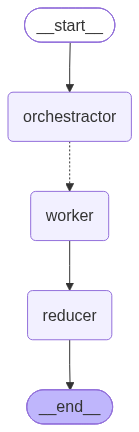

In [35]:
app

In [36]:
out=app.invoke({"topic": "Write a blog on Self Attention","sections": []})

In [32]:
print(out["final"])

# Unpacking Self-Attention: The Core of Modern AI Models

## Introduction to Self-Attention: Beyond Recurrent and Convolutional Limitations

Traditional sequence models like Recurrent Neural Networks (RNNs) and Convolutional Neural Networks (CNNs) face inherent limitations when processing complex sequential data. RNNs process tokens one by one, making them slow and prone to forgetting information from distant past tokens, a challenge known as the long-range dependency problem. CNNs, while effective for local features, rely on fixed-size receptive fields, struggling to capture global contextual relationships across an entire sequence without many layers or large kernels.

Self-Attention addresses these issues by allowing each token in a sequence to dynamically weigh the importance of all other tokens. Instead of processing sequentially or locally, a token can "look" at every other token simultaneously, computing a relevance score that indicates how much each other token contributes to i